In [1]:
import pandas as pd

fff = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF.csv")

print(fff.shape)
print(fff.columns.tolist())

(7762, 55)
['code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'ass_1_date', 'ass_1_score', 'ass_2_date', 'ass_2_score', 'ass_3_date', 'ass_3_score', 'ass_4_date', 'ass_4_score', 'ass_5_date', 'ass_5_score', 'ass_6_date', 'ass_6_score', 'ass_7_date', 'ass_7_score', 'ass_8_date', 'ass_8_score', 'ass_9_date', 'ass_9_score', 'ass_10_date', 'ass_10_score', 'ass_11_date', 'ass_11_score', 'ass_12_date', 'ass_12_score', 'clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng', 'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [3]:
demographics = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                 'num_of_prev_attempts', 'studied_credits', 'disability']

assessment_cols = [f'ass_{i}_score' for i in range(1, 13)]

click_cols = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
              'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
              'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
              'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource',
              'clicks_subpage', 'clicks_url']

selected_cols = demographics + assessment_cols + click_cols + ['final_result']

fff_sel = fff[selected_cols].copy()
print(fff_sel.shape)
fff_sel.head()

(7762, 39)


,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,ass_1_score,ass_2_score,...,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_subpage,clicks_url,final_result
0,F,South East Region,A Level or Equivalent,30-40%,0-35,0,60,N,86.0,94.0,...,42.0,54.0,15.0,26.0,848.0,NaN,44.0,380.0,50.0,Distinction
1,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,94.0,78.0,...,0.0,19.0,9.0,18.0,460.0,NaN,24.0,198.0,25.0,Pass
2,M,South West Region,A Level or Equivalent,10-20,0-35,0,60,N,86.0,82.0,...,0.0,18.0,10.0,18.0,536.0,NaN,25.0,165.0,25.0,Pass
3,M,West Midlands Region,Lower Than A Level,70-80%,0-35,0,120,Y,84.0,66.0,...,4.0,0.0,7.0,0.0,286.0,NaN,13.0,54.0,11.0,Withdrawn
4,M,South Region,Lower Than A Level,40-50%,0-35,0,90,N,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Withdrawn


In [5]:
print("imd_band unique values:")
print(fff_sel['imd_band'].unique())
print()
print("imd_band NaN count:", fff_sel['imd_band'].isna().sum())
print()
print("NaN counts - assessment scores:")
print(fff_sel[assessment_cols].isna().sum())
print()
print("NaN counts - click columns:")
print(fff_sel[click_cols].isna().sum())

imd_band unique values:
['30-40%' '80-90%' '10-20' '70-80%' '40-50%' nan '60-70%' '50-60%' '0-10%'
 '90-100%' '20-30%']

imd_band NaN count: 367

NaN counts - assessment scores:
ass_1_score     1536
ass_2_score     2222
ass_3_score     3011
ass_4_score     3373
ass_5_score     3891
ass_6_score     2812
ass_7_score     3174
ass_8_score     3519
ass_9_score     3627
ass_10_score    3714
ass_11_score    3694
ass_12_score    3802
dtype: int64

NaN counts - click columns:
clicks_dataplus           670
clicks_dualpane           670
clicks_folder            4301
clicks_forumng            670
clicks_glossary           670
clicks_homepage           670
clicks_htmlactivity      5641
clicks_oucollaborate     2180
clicks_oucontent          670
clicks_ouelluminate      6252
clicks_ouwiki             670
clicks_page               670
clicks_questionnaire      670
clicks_quiz               670
clicks_repeatactivity    3543
clicks_resource           670
clicks_subpage            670
clicks_url        

In [7]:
fff_sel['imd_band'] = fff_sel['imd_band'].replace('10-20', '10-20%')

imd_mode = fff_sel['imd_band'].mode()[0]
print("imd_band mode:", imd_mode)
fff_sel['imd_band'] = fff_sel['imd_band'].fillna(imd_mode)

print(fff_sel['imd_band'].unique())

fff_sel[assessment_cols] = fff_sel[assessment_cols].fillna(-1)
fff_sel[click_cols] = fff_sel[click_cols].fillna(0)

print(fff_sel.isna().sum().sum())

imd_band mode: 30-40%
['30-40%' '80-90%' '10-20%' '70-80%' '40-50%' '60-70%' '50-60%' '0-10%'
 '90-100%' '20-30%']
0


In [9]:
final_result_map = {'Withdrawn': 0, 'Fail': 1, 'Pass': 2, 'Distinction': 3}
fff_sel['final_result'] = fff_sel['final_result'].map(final_result_map)

highest_ed_order = ['No Formal quals', 'Lower Than A Level', 'A Level or Equivalent',
                     'HE Qualification', 'Post Graduate Qualification']
highest_ed_map = {v: i for i, v in enumerate(highest_ed_order)}
fff_sel['highest_education'] = fff_sel['highest_education'].map(highest_ed_map)

imd_order = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%',
             '60-70%', '70-80%', '80-90%', '90-100%']
imd_map = {v: i for i, v in enumerate(imd_order)}
fff_sel['imd_band'] = fff_sel['imd_band'].map(imd_map)

age_band_order = ['0-35', '35-55', '55<=']
age_band_map = {v: i for i, v in enumerate(age_band_order)}
fff_sel['age_band'] = fff_sel['age_band'].map(age_band_map)

fff_sel['gender'] = fff_sel['gender'].map({'M': 0, 'F': 1})
fff_sel['disability'] = fff_sel['disability'].map({'N': 0, 'Y': 1})

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
fff_sel['region'] = le.fit_transform(fff_sel['region'])

print(fff_sel.isna().sum().sum())
print(fff_sel.dtypes)

0
gender                     int64
region                     int64
highest_education          int64
imd_band                   int64
age_band                   int64
num_of_prev_attempts       int64
studied_credits            int64
disability                 int64
ass_1_score              float64
ass_2_score              float64
ass_3_score              float64
ass_4_score              float64
ass_5_score              float64
ass_6_score              float64
ass_7_score              float64
ass_8_score              float64
ass_9_score              float64
ass_10_score             float64
ass_11_score             float64
ass_12_score             float64
clicks_dataplus          float64
clicks_dualpane          float64
clicks_folder            float64
clicks_forumng           float64
clicks_glossary          float64
clicks_homepage          float64
clicks_htmlactivity      float64
clicks_oucollaborate     float64
clicks_oucontent         float64
clicks_ouelluminate      float64
clicks_o

In [11]:
for col in click_cols:
    nonzero = (fff_sel[col] != 0).sum()
    unique_vals = fff_sel[col].nunique()
    print(f"{col}: {nonzero} nonzero / {unique_vals} unique values")

clicks_dataplus: 2326 nonzero / 91 unique values
clicks_dualpane: 2648 nonzero / 41 unique values
clicks_folder: 1934 nonzero / 14 unique values
clicks_forumng: 6741 nonzero / 1263 unique values
clicks_glossary: 701 nonzero / 59 unique values
clicks_homepage: 7084 nonzero / 1223 unique values
clicks_htmlactivity: 1918 nonzero / 26 unique values
clicks_oucollaborate: 3172 nonzero / 72 unique values
clicks_oucontent: 6946 nonzero / 2481 unique values
clicks_ouelluminate: 1211 nonzero / 109 unique values
clicks_ouwiki: 5423 nonzero / 208 unique values
clicks_page: 6251 nonzero / 65 unique values
clicks_questionnaire: 3792 nonzero / 66 unique values
clicks_quiz: 6226 nonzero / 1540 unique values
clicks_repeatactivity: 3 nonzero / 4 unique values
clicks_resource: 6686 nonzero / 192 unique values
clicks_subpage: 6948 nonzero / 827 unique values
clicks_url: 6376 nonzero / 182 unique values


In [13]:
click_cols_final = [c for c in click_cols if c != 'clicks_repeatactivity']

fff_sel['total_clicks'] = fff_sel[click_cols_final].sum(axis=1)
fff_sel = fff_sel.drop(columns=click_cols)  # drops all 18, including repeatactivity

bin_cols = assessment_cols + ['total_clicks']

for col in bin_cols:
    binned = pd.qcut(fff_sel[col], q=4, duplicates='drop')
    n_bins = binned.nunique()
    print(f"{col}: {n_bins} bins")
    fff_sel[col] = binned.cat.codes

print()
print("Final shape:", fff_sel.shape)
print(fff_sel.columns.tolist())

ass_1_score: 4 bins
ass_2_score: 3 bins
ass_3_score: 3 bins
ass_4_score: 3 bins
ass_5_score: 2 bins
ass_6_score: 3 bins
ass_7_score: 3 bins
ass_8_score: 3 bins
ass_9_score: 3 bins
ass_10_score: 3 bins
ass_11_score: 3 bins
ass_12_score: 3 bins
total_clicks: 4 bins

Final shape: (7762, 22)
['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'ass_1_score', 'ass_2_score', 'ass_3_score', 'ass_4_score', 'ass_5_score', 'ass_6_score', 'ass_7_score', 'ass_8_score', 'ass_9_score', 'ass_10_score', 'ass_11_score', 'ass_12_score', 'final_result', 'total_clicks']


In [15]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
import numpy as np

data = fff_sel.values.astype(float)
node_names = fff_sel.columns.tolist()

nodes = {name: GraphNode(name) for name in node_names}

assessment_cols_fff = [f'ass_{i}_score' for i in range(1, 13)]
demo_vars = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
             'num_of_prev_attempts', 'studied_credits', 'disability']
course_time_vars = assessment_cols_fff + ['total_clicks', 'final_result']

bk = BackgroundKnowledge()

# Rule 1
for ct in course_time_vars:
    for d in demo_vars:
        bk.add_forbidden_by_node(nodes[ct], nodes[d])

# Rule 2
for name in node_names:
    if name != 'gender':
        bk.add_forbidden_by_node(nodes[name], nodes['gender'])

# Rule 3
for i in range(1, 13):
    for j in range(1, 13):
        if j > i:
            bk.add_forbidden_by_node(nodes[f'ass_{j}_score'], nodes[f'ass_{i}_score'])

# Rule 4
for ct in course_time_vars:
    bk.add_forbidden_by_node(nodes[ct], nodes['studied_credits'])
    bk.add_forbidden_by_node(nodes[ct], nodes['num_of_prev_attempts'])

# Rule 5
for a in assessment_cols_fff:
    bk.add_forbidden_by_node(nodes['final_result'], nodes[a])

# Rule 6
for a in assessment_cols_fff:
    bk.add_forbidden_by_node(nodes[a], nodes['total_clicks'])

# Rule 7
bk.add_forbidden_by_node(nodes['final_result'], nodes['total_clicks'])

cg = pc(data, alpha=0.05, indep_test='gsq', background_knowledge=bk, node_names=node_names)

print("PC complete.")
print("Number of edges:", cg.G.get_num_edges())

  0%|          | 0/22 [00:00<?, ?it/s]

PC complete.
Number of edges: 78


In [17]:
edges = cg.G.get_graph_edges()
for edge in edges:
    print(edge)

gender --> studied_credits
gender --> total_clicks
highest_education --> region
imd_band --> region
region --- disability
region --> ass_1_score
imd_band --> highest_education
age_band --> highest_education
highest_education --> disability
imd_band --> disability
age_band --> total_clicks
num_of_prev_attempts --> studied_credits
ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> final_result
total_clicks --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
ass_2_score --> ass_6_score
ass_2_score --> ass_8_score
ass_2_score --> final_result
total_clicks --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_6_score
ass_3_score --> ass_7_score
ass_3_score --> ass_8_score
ass_3_score --> ass_9_score
ass_3_score --> final_result
total_clicks --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_7_score
ass_4_score --> ass_8_score
ass_4_score --> ass

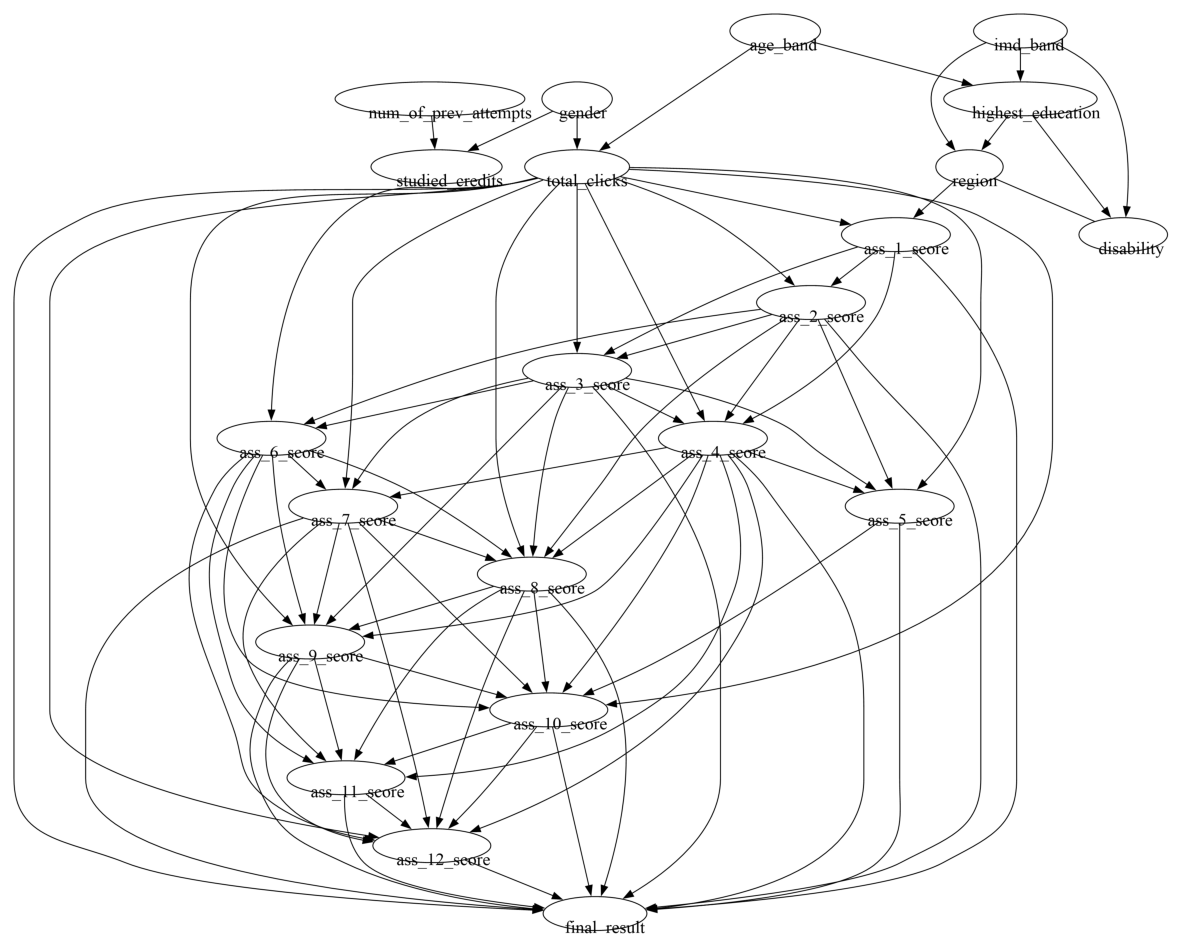

In [19]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

pyd = GraphUtils.to_pydot(cg.G, labels=node_names)
png_data = pyd.create_png(prog=dot_path)

img = mpimg.imread(io.BytesIO(png_data))
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis('off')
plt.show()

## Domain specific DAGs

In [24]:
df = fff

print(df.shape)
print(df[['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'final_result']].dtypes)
print(df[['gender', 'highest_education', 'final_result']].head(3))

(7762, 55)
gender               object
region               object
highest_education    object
imd_band             object
age_band             object
disability           object
final_result         object
dtype: object
  gender      highest_education final_result
0      F  A Level or Equivalent  Distinction
1      M  A Level or Equivalent         Pass
2      M  A Level or Equivalent         Pass


In [26]:
final_result_map = {'Withdrawn':0,'Fail':1,'Pass':2,'Distinction':3}
education_map = {'No Formal quals':0,'Lower Than A Level':1,'A Level or Equivalent':2,
                  'HE Qualification':3,'Post Graduate Qualification':4}
age_band_map = {'0-35':0,'35-55':1,'55<=':2}

print(df['imd_band'].unique())

df['final_result'] = df['final_result'].map(final_result_map)
df['highest_education'] = df['highest_education'].map(education_map)
df['age_band'] = df['age_band'].map(age_band_map)
df['gender'] = df['gender'].map({'M':0,'F':1})
df['disability'] = df['disability'].map({'N':0,'Y':1})
df['region'] = df['region'].astype('category').cat.codes

print(df[['gender', 'highest_education', 'age_band', 'final_result']].isnull().sum())

['30-40%' '80-90%' '10-20' '70-80%' '40-50%' nan '60-70%' '50-60%' '0-10%'
 '90-100%' '20-30%']
gender               0
highest_education    0
age_band             0
final_result         0
dtype: int64


In [28]:
imd_map = {'0-10%':0,'10-20%':1,'10-20':1,'20-30%':2,'30-40%':3,'40-50%':4,
           '50-60%':5,'60-70%':6,'70-80%':7,'80-90%':8,'90-100%':9}

df['imd_band'] = df['imd_band'].map(imd_map)

print("NaN before mode-fill:", df['imd_band'].isnull().sum())

imd_mode = df['imd_band'].mode()[0]
df['imd_band'] = df['imd_band'].fillna(imd_mode)

print("NaN after mode-fill:", df['imd_band'].isnull().sum())
print("Mode used:", imd_mode)

NaN before mode-fill: 367
NaN after mode-fill: 0
Mode used: 3.0


In [30]:
demo_cols_fff = ['gender', 'region', 'highest_education', 'imd_band', 'age_band',
                  'num_of_prev_attempts', 'studied_credits', 'disability']

dag1_data_fff = df[demo_cols_fff + ['final_result']].copy()

print(dag1_data_fff.shape)
print(dag1_data_fff.isnull().sum())

(7762, 9)
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64


In [32]:
node_names_dag1_fff = list(dag1_data_fff.columns)
nodes_dag1_fff = [GraphNode(name) for name in node_names_dag1_fff]

bk1_fff = BackgroundKnowledge()

gender_node_fff = nodes_dag1_fff[node_names_dag1_fff.index('gender')]
final_result_node_fff = nodes_dag1_fff[node_names_dag1_fff.index('final_result')]

# Rule 2: nothing causes gender (root)
for n in nodes_dag1_fff:
    if n != gender_node_fff:
        bk1_fff.add_forbidden_by_node(n, gender_node_fff)

# Rule 1 (generalized): final_result cannot cause any demographic
for n in nodes_dag1_fff:
    if n != final_result_node_fff:
        bk1_fff.add_forbidden_by_node(final_result_node_fff, n)

# Sanity check
highest_education_node_fff = nodes_dag1_fff[node_names_dag1_fff.index('highest_education')]
print("highest_education -> gender forbidden:", bk1_fff.is_forbidden(highest_education_node_fff, gender_node_fff))
print("final_result -> studied_credits forbidden:", bk1_fff.is_forbidden(final_result_node_fff, nodes_dag1_fff[node_names_dag1_fff.index('studied_credits')]))

highest_education -> gender forbidden: True
final_result -> studied_credits forbidden: True


In [34]:
data1_fff = dag1_data_fff.to_numpy()

cg1_fff = pc(data1_fff, alpha=0.05, indep_test='gsq', background_knowledge=bk1_fff, node_names=node_names_dag1_fff)

print("Number of edges:", cg1_fff.G.get_num_edges())

  0%|          | 0/9 [00:00<?, ?it/s]

Number of edges: 17


In [36]:
for edge in cg1_fff.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

gender [TAIL] -- [ARROW] region
gender [TAIL] -- [ARROW] studied_credits
highest_education [TAIL] -- [ARROW] region
imd_band [TAIL] -- [ARROW] region
disability [TAIL] -- [ARROW] region
region [TAIL] -- [ARROW] final_result
highest_education [TAIL] -- [TAIL] imd_band
highest_education [TAIL] -- [TAIL] age_band
highest_education [TAIL] -- [TAIL] disability
highest_education [TAIL] -- [ARROW] final_result
imd_band [TAIL] -- [TAIL] disability
imd_band [TAIL] -- [ARROW] final_result
age_band [TAIL] -- [ARROW] final_result
num_of_prev_attempts [TAIL] -- [ARROW] studied_credits
num_of_prev_attempts [TAIL] -- [ARROW] final_result
studied_credits [TAIL] -- [ARROW] final_result
disability [TAIL] -- [ARROW] final_result


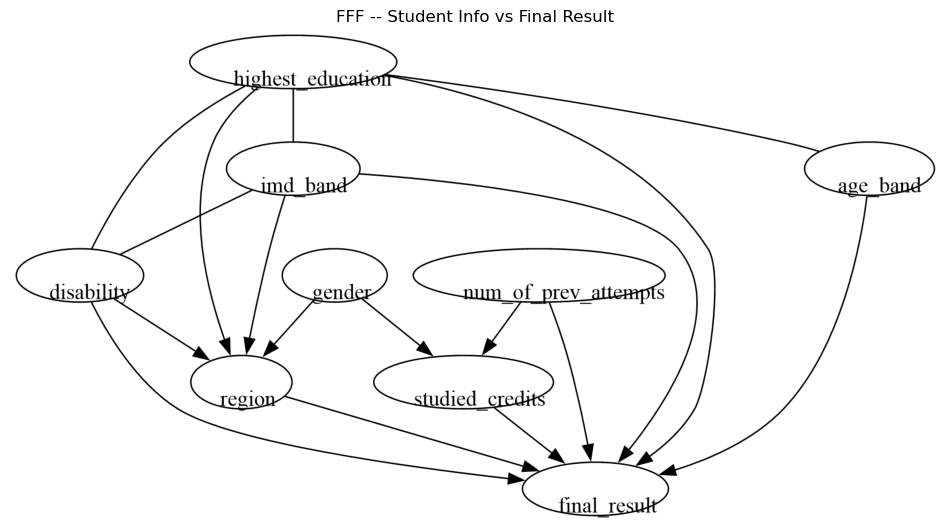

In [38]:
pyd1_fff = GraphUtils.to_pydot(cg1_fff.G, labels=node_names_dag1_fff)

for node in pyd1_fff.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes1_fff = pyd1_fff.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF_DAG1_studentinfo_vs_finalresult.png", "wb") as f:
    f.write(png_bytes1_fff)

img1_fff = mpimg.imread(io.BytesIO(png_bytes1_fff), format='png')
plt.figure(figsize=(12, 10))
plt.imshow(img1_fff)
plt.axis('off')
plt.title("FFF -- Student Info vs Final Result")
plt.show()

## assessments vs final_result

In [41]:
ass_cols_fff = [f'ass_{i}_score' for i in range(1, 13)]

df[ass_cols_fff] = df[ass_cols_fff].fillna(-1)

dag2_data_fff = df[ass_cols_fff + ['final_result']].copy()

for col in ass_cols_fff:
    dag2_data_fff[col] = pd.qcut(dag2_data_fff[col], q=4, labels=False, duplicates='drop')

print(dag2_data_fff.shape)
print(dag2_data_fff.nunique())

(7762, 13)
ass_1_score     4
ass_2_score     3
ass_3_score     3
ass_4_score     3
ass_5_score     2
ass_6_score     3
ass_7_score     3
ass_8_score     3
ass_9_score     3
ass_10_score    3
ass_11_score    3
ass_12_score    3
final_result    4
dtype: int64


In [43]:
node_names_dag2_fff = list(dag2_data_fff.columns)
nodes_dag2_fff = [GraphNode(name) for name in node_names_dag2_fff]

bk2_fff = BackgroundKnowledge()

final_result_node2_fff = nodes_dag2_fff[node_names_dag2_fff.index('final_result')]

# Rule 5: final_result cannot cause any assessment
for n in nodes_dag2_fff:
    if n != final_result_node2_fff:
        bk2_fff.add_forbidden_by_node(final_result_node2_fff, n)

# Rule 3: sequential order -- ass_j cannot cause ass_i if j > i
for j in range(1, 13):
    for i in range(1, j):
        node_j = nodes_dag2_fff[node_names_dag2_fff.index(f'ass_{j}_score')]
        node_i = nodes_dag2_fff[node_names_dag2_fff.index(f'ass_{i}_score')]
        bk2_fff.add_forbidden_by_node(node_j, node_i)

# Sanity check
ass1_node_fff = nodes_dag2_fff[node_names_dag2_fff.index('ass_1_score')]
ass11_node_fff = nodes_dag2_fff[node_names_dag2_fff.index('ass_11_score')]
print("ass_11 -> ass_1 forbidden:", bk2_fff.is_forbidden(ass11_node_fff, ass1_node_fff))
print("final_result -> ass_1 forbidden:", bk2_fff.is_forbidden(final_result_node2_fff, ass1_node_fff))

ass_11 -> ass_1 forbidden: True
final_result -> ass_1 forbidden: True


In [45]:
data2_fff = dag2_data_fff.to_numpy()

cg2_fff = pc(data2_fff, alpha=0.05, indep_test='gsq', background_knowledge=bk2_fff, node_names=node_names_dag2_fff)

print("Number of edges:", cg2_fff.G.get_num_edges())

  0%|          | 0/13 [00:00<?, ?it/s]

Number of edges: 57


In [47]:
for edge in cg2_fff.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

ass_1_score [TAIL] -- [ARROW] ass_2_score
ass_1_score [TAIL] -- [ARROW] ass_3_score
ass_1_score [TAIL] -- [ARROW] ass_4_score
ass_1_score [TAIL] -- [ARROW] ass_6_score
ass_1_score [TAIL] -- [ARROW] ass_7_score
ass_1_score [TAIL] -- [ARROW] final_result
ass_2_score [TAIL] -- [ARROW] ass_3_score
ass_2_score [TAIL] -- [ARROW] ass_4_score
ass_2_score [TAIL] -- [ARROW] ass_5_score
ass_2_score [TAIL] -- [ARROW] ass_6_score
ass_2_score [TAIL] -- [ARROW] ass_8_score
ass_2_score [TAIL] -- [ARROW] final_result
ass_3_score [TAIL] -- [ARROW] ass_4_score
ass_3_score [TAIL] -- [ARROW] ass_5_score
ass_3_score [TAIL] -- [ARROW] ass_6_score
ass_3_score [TAIL] -- [ARROW] ass_7_score
ass_3_score [TAIL] -- [ARROW] ass_8_score
ass_3_score [TAIL] -- [ARROW] ass_9_score
ass_3_score [TAIL] -- [ARROW] final_result
ass_4_score [TAIL] -- [ARROW] ass_5_score
ass_4_score [TAIL] -- [ARROW] ass_6_score
ass_4_score [TAIL] -- [ARROW] ass_7_score
ass_4_score [TAIL] -- [ARROW] ass_8_score
ass_4_score [TAIL] -- [ARROW] a

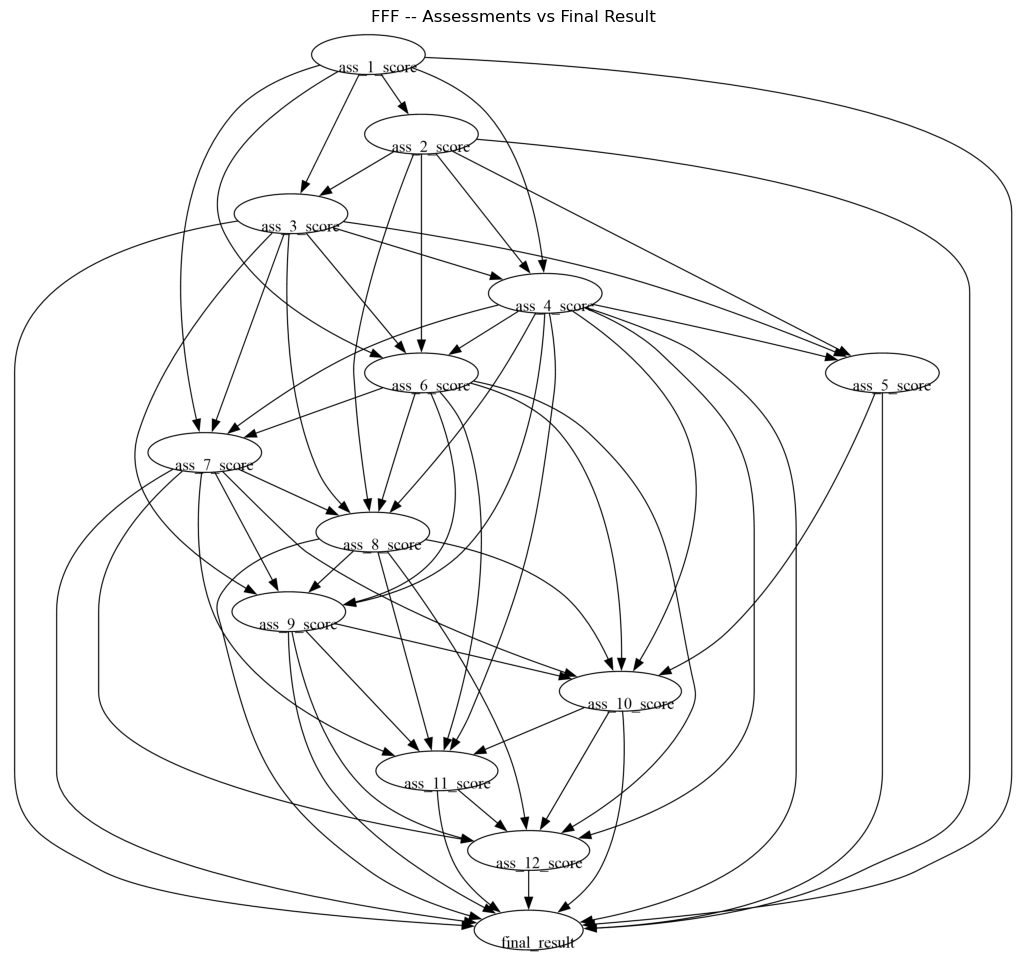

In [49]:
pyd2_fff = GraphUtils.to_pydot(cg2_fff.G, labels=node_names_dag2_fff)

for node in pyd2_fff.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes2_fff = pyd2_fff.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF_DAG2_assessments_vs_finalresult.png", "wb") as f:
    f.write(png_bytes2_fff)

img2_fff = mpimg.imread(io.BytesIO(png_bytes2_fff), format='png')
plt.figure(figsize=(14, 12))
plt.imshow(img2_fff)
plt.axis('off')
plt.title("FFF -- Assessments vs Final Result")
plt.show()

## individual clicks vs final_result

In [52]:
raw_click_cols_fff = ['clicks_dataplus', 'clicks_dualpane', 'clicks_folder', 'clicks_forumng',
                       'clicks_glossary', 'clicks_homepage', 'clicks_htmlactivity', 'clicks_oucollaborate',
                       'clicks_oucontent', 'clicks_ouelluminate', 'clicks_ouwiki', 'clicks_page',
                       'clicks_questionnaire', 'clicks_quiz', 'clicks_repeatactivity', 'clicks_resource',
                       'clicks_subpage', 'clicks_url']

clicks_raw_fff = df[raw_click_cols_fff].fillna(0)

for col in raw_click_cols_fff:
    print(col, "nonzero:", (clicks_raw_fff[col] > 0).sum(), "unique:", clicks_raw_fff[col].nunique())

clicks_dataplus nonzero: 2326 unique: 91
clicks_dualpane nonzero: 2648 unique: 41
clicks_folder nonzero: 1934 unique: 14
clicks_forumng nonzero: 6741 unique: 1263
clicks_glossary nonzero: 701 unique: 59
clicks_homepage nonzero: 7084 unique: 1223
clicks_htmlactivity nonzero: 1918 unique: 26
clicks_oucollaborate nonzero: 3172 unique: 72
clicks_oucontent nonzero: 6946 unique: 2481
clicks_ouelluminate nonzero: 1211 unique: 109
clicks_ouwiki nonzero: 5423 unique: 208
clicks_page nonzero: 6251 unique: 65
clicks_questionnaire nonzero: 3792 unique: 66
clicks_quiz nonzero: 6226 unique: 1540
clicks_repeatactivity nonzero: 3 unique: 4
clicks_resource nonzero: 6686 unique: 192
clicks_subpage nonzero: 6948 unique: 827
clicks_url nonzero: 6376 unique: 182


In [54]:
raw_click_cols_fff_clean = [c for c in raw_click_cols_fff if c != 'clicks_repeatactivity']

dag3_data_fff = clicks_raw_fff[raw_click_cols_fff_clean].copy()

for col in raw_click_cols_fff_clean:
    dag3_data_fff[col] = pd.qcut(dag3_data_fff[col], q=4, labels=False, duplicates='drop')

dag3_data_fff['final_result'] = df['final_result'].values

print(dag3_data_fff.shape)
for col in dag3_data_fff.columns:
    print(col, dag3_data_fff[col].nunique())

(7762, 18)
clicks_dataplus 2
clicks_dualpane 2
clicks_folder 1
clicks_forumng 4
clicks_glossary 1
clicks_homepage 4
clicks_htmlactivity 1
clicks_oucollaborate 2
clicks_oucontent 4
clicks_ouelluminate 1
clicks_ouwiki 3
clicks_page 4
clicks_questionnaire 2
clicks_quiz 4
clicks_resource 4
clicks_subpage 4
clicks_url 4
final_result 4


In [56]:
cols_to_drop_fff = ['clicks_folder', 'clicks_glossary', 'clicks_htmlactivity', 'clicks_ouelluminate']

dag3_data_fff_final = dag3_data_fff.drop(columns=cols_to_drop_fff)

print(dag3_data_fff_final.shape)
print(dag3_data_fff_final.nunique())

(7762, 14)
clicks_dataplus         2
clicks_dualpane         2
clicks_forumng          4
clicks_homepage         4
clicks_oucollaborate    2
clicks_oucontent        4
clicks_ouwiki           3
clicks_page             4
clicks_questionnaire    2
clicks_quiz             4
clicks_resource         4
clicks_subpage          4
clicks_url              4
final_result            4
dtype: int64


In [58]:
node_names_dag3_fff = list(dag3_data_fff_final.columns)
nodes_dag3_fff = [GraphNode(name) for name in node_names_dag3_fff]

bk3_fff = BackgroundKnowledge()

final_result_node3_fff = nodes_dag3_fff[node_names_dag3_fff.index('final_result')]

# Rule 6 (per-column): final_result cannot cause any individual click variable
for n in nodes_dag3_fff:
    if n != final_result_node3_fff:
        bk3_fff.add_forbidden_by_node(final_result_node3_fff, n)

# Sanity check
clicks_resource_node_fff = nodes_dag3_fff[node_names_dag3_fff.index('clicks_resource')]
print("final_result -> clicks_resource forbidden:", bk3_fff.is_forbidden(final_result_node3_fff, clicks_resource_node_fff))

final_result -> clicks_resource forbidden: True


In [60]:
data3_fff = dag3_data_fff_final.to_numpy()

cg3_fff = pc(data3_fff, alpha=0.05, indep_test='gsq', background_knowledge=bk3_fff, node_names=node_names_dag3_fff)

print("Number of edges:", cg3_fff.G.get_num_edges())

  0%|          | 0/14 [00:00<?, ?it/s]

Number of edges: 51


In [62]:
for edge in cg3_fff.G.get_graph_edges():
    node1 = edge.get_node1()
    node2 = edge.get_node2()
    ep1 = edge.get_endpoint1()
    ep2 = edge.get_endpoint2()
    print(f"{node1.get_name()} [{ep1}] -- [{ep2}] {node2.get_name()}")

clicks_oucontent [TAIL] -- [ARROW] clicks_dataplus
clicks_page [TAIL] -- [ARROW] clicks_dataplus
clicks_questionnaire [TAIL] -- [ARROW] clicks_dataplus
clicks_url [TAIL] -- [ARROW] clicks_dataplus
clicks_dataplus [TAIL] -- [ARROW] final_result
clicks_dualpane [TAIL] -- [ARROW] clicks_ouwiki
clicks_dualpane [TAIL] -- [ARROW] clicks_page
clicks_dualpane [TAIL] -- [TAIL] clicks_questionnaire
clicks_dualpane [TAIL] -- [ARROW] clicks_resource
clicks_forumng [TAIL] -- [ARROW] clicks_homepage
clicks_oucollaborate [TAIL] -- [ARROW] clicks_forumng
clicks_oucontent [TAIL] -- [ARROW] clicks_forumng
clicks_ouwiki [TAIL] -- [ARROW] clicks_forumng
clicks_page [TAIL] -- [ARROW] clicks_forumng
clicks_quiz [TAIL] -- [ARROW] clicks_forumng
clicks_forumng [TAIL] -- [ARROW] clicks_resource
clicks_subpage [TAIL] -- [ARROW] clicks_forumng
clicks_url [TAIL] -- [ARROW] clicks_forumng
clicks_forumng [TAIL] -- [ARROW] final_result
clicks_oucontent [TAIL] -- [ARROW] clicks_homepage
clicks_ouwiki [TAIL] -- [ARROW

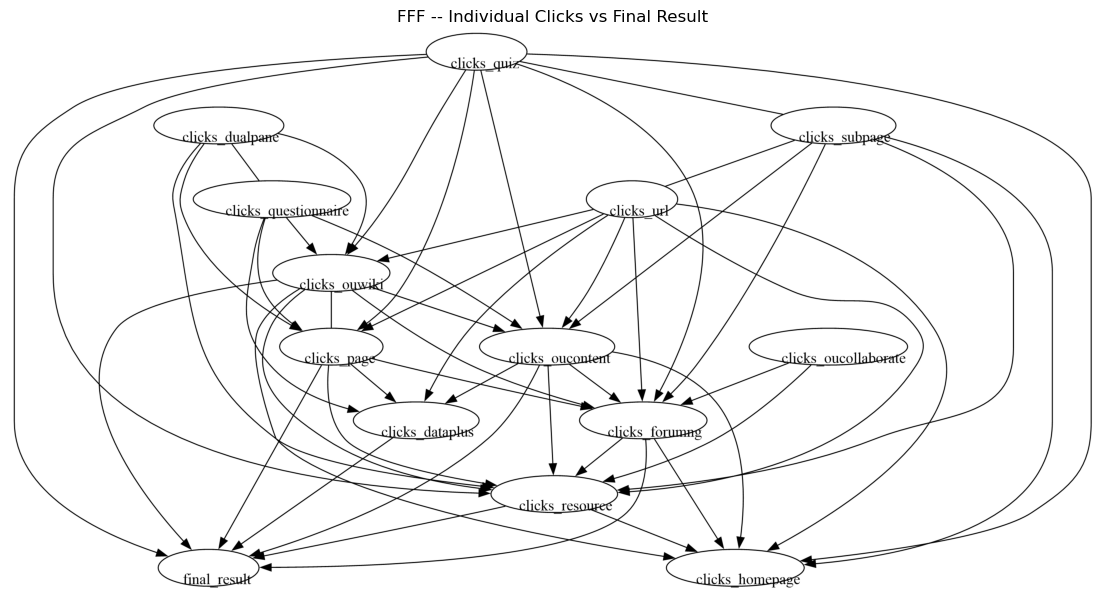

In [64]:
pyd3_fff = GraphUtils.to_pydot(cg3_fff.G, labels=node_names_dag3_fff)

for node in pyd3_fff.get_nodes():
    node.set_fontsize('11')
    node.set_fixedsize('false')
    node.set_margin('0.15,0.08')

png_bytes3_fff = pyd3_fff.create_png(prog=dot_path)

with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF_DAG3_clicks_vs_finalresult.png", "wb") as f:
    f.write(png_bytes3_fff)

img3_fff = mpimg.imread(io.BytesIO(png_bytes3_fff), format='png')
plt.figure(figsize=(14, 12))
plt.imshow(img3_fff)
plt.axis('off')
plt.title("FFF -- Individual Clicks vs Final Result")
plt.show()

## assessment vs VLE clicks

In [6]:
import pandas as pd

df_fff_raw = pd.read_csv(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF.csv")

print(df_fff_raw.shape)
df_fff_raw.head()

(7762, 55)


,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,...,clicks_oucontent,clicks_ouelluminate,clicks_ouwiki,clicks_page,clicks_questionnaire,clicks_quiz,clicks_repeatactivity,clicks_resource,clicks_subpage,clicks_url
0,2013B,33915,F,South East Region,A Level or Equivalent,30-40%,0-35,0,60,N,...,1590.0,42.0,54.0,15.0,26.0,848.0,NaN,44.0,380.0,50.0
1,2013B,35544,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,...,943.0,0.0,19.0,9.0,18.0,460.0,NaN,24.0,198.0,25.0
2,2013B,35860,M,South West Region,A Level or Equivalent,10-20,0-35,0,60,N,...,1070.0,0.0,18.0,10.0,18.0,536.0,NaN,25.0,165.0,25.0
3,2013B,36385,M,West Midlands Region,Lower Than A Level,70-80%,0-35,0,120,Y,...,79.0,4.0,0.0,7.0,0.0,286.0,NaN,13.0,54.0,11.0
4,2013B,36842,M,South Region,Lower Than A Level,40-50%,0-35,0,90,N,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
ass_cols_fff = [f"ass_{i}_score" for i in range(1, 13)]
click_cols_fff = [col for col in df_fff_raw.columns if col.startswith('clicks_')]

# drop clicks_repeatactivity pre-binning, near-zero variation (3/7762 nonzero previously)
click_cols_fff = [col for col in click_cols_fff if col != 'clicks_repeatactivity']

df_fff_sel = df_fff_raw[ass_cols_fff + click_cols_fff].copy()

# scores NaN -> -1, clicks NaN -> 0
df_fff_sel[ass_cols_fff] = df_fff_sel[ass_cols_fff].fillna(-1)
df_fff_sel[click_cols_fff] = df_fff_sel[click_cols_fff].fillna(0)

# quartile binning
for col in ass_cols_fff + click_cols_fff:
    df_fff_sel[col] = pd.qcut(df_fff_sel[col], q=4, labels=False, duplicates='drop')

print(df_fff_sel.shape)
df_fff_sel.nunique()

(7762, 29)


ass_1_score             4
ass_2_score             3
ass_3_score             3
ass_4_score             3
ass_5_score             2
ass_6_score             3
ass_7_score             3
ass_8_score             3
ass_9_score             3
ass_10_score            3
ass_11_score            3
ass_12_score            3
clicks_dataplus         2
clicks_dualpane         2
clicks_folder           1
clicks_forumng          4
clicks_glossary         1
clicks_homepage         4
clicks_htmlactivity     1
clicks_oucollaborate    2
clicks_oucontent        4
clicks_ouelluminate     1
clicks_ouwiki           3
clicks_page             4
clicks_questionnaire    2
clicks_quiz             4
clicks_resource         4
clicks_subpage          4
clicks_url              4
dtype: int64

In [10]:
drop_cols_fff = ['clicks_folder', 'clicks_glossary', 'clicks_htmlactivity', 'clicks_ouelluminate']

df_fff_sel = df_fff_sel.drop(columns=drop_cols_fff)
click_cols_fff = [col for col in click_cols_fff if col not in drop_cols_fff]

print(df_fff_sel.shape)
print(click_cols_fff)

(7762, 25)
['clicks_dataplus', 'clicks_dualpane', 'clicks_forumng', 'clicks_homepage', 'clicks_oucollaborate', 'clicks_oucontent', 'clicks_ouwiki', 'clicks_page', 'clicks_questionnaire', 'clicks_quiz', 'clicks_resource', 'clicks_subpage', 'clicks_url']


In [14]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledgeOrientUtils import *
from causallearn.graph.GraphNode import GraphNode
from causallearn.utils.cit import CIT

In [15]:
node_names_fff = list(df_fff_sel.columns)
data_fff = df_fff_sel.values

bk_fff = BackgroundKnowledge()

# Rule 3: sequential assessment order
for i in range(1, 13):
    for j in range(1, 13):
        if j > i:
            bk_fff.add_forbidden_by_node(
                GraphNode(f"ass_{j}_score"), GraphNode(f"ass_{i}_score")
            )

# Rule 6 variant: assessment scores cannot cause clicks
for ass in ass_cols_fff:
    for click in click_cols_fff:
        bk_fff.add_forbidden_by_node(GraphNode(ass), GraphNode(click))

cg_fff = pc(data_fff, 0.05, 'gsq', node_names=node_names_fff, background_knowledge=bk_fff, depth=3, show_progress=True)
print(cg_fff.G.get_num_edges())

  0%|          | 0/25 [00:00<?, ?it/s]

107


In [18]:
for edge in cg_fff.G.get_graph_edges():
    print(edge)

ass_1_score --> ass_2_score
ass_1_score --> ass_3_score
ass_1_score --> ass_4_score
ass_1_score --> ass_6_score
clicks_forumng --> ass_1_score
clicks_oucontent --> ass_1_score
clicks_quiz --> ass_1_score
clicks_resource --> ass_1_score
clicks_subpage --> ass_1_score
ass_2_score --> ass_3_score
ass_2_score --> ass_4_score
ass_2_score --> ass_5_score
ass_2_score --> ass_6_score
ass_2_score --> ass_8_score
clicks_forumng --> ass_2_score
ass_3_score --> ass_4_score
ass_3_score --> ass_5_score
ass_3_score --> ass_6_score
ass_3_score --> ass_7_score
ass_3_score --> ass_8_score
ass_3_score --> ass_9_score
clicks_oucontent --> ass_3_score
ass_4_score --> ass_5_score
ass_4_score --> ass_6_score
ass_4_score --> ass_7_score
ass_4_score --> ass_8_score
ass_4_score --> ass_9_score
ass_4_score --> ass_10_score
ass_4_score --> ass_11_score
ass_4_score --> ass_12_score
clicks_resource --> ass_4_score
ass_5_score --> ass_11_score
clicks_oucontent --> ass_5_score
ass_6_score --> ass_7_score
ass_6_score 

In [30]:
from causallearn.utils.GraphUtils import GraphUtils
dot_path = r"C:\Users\Disha Sharma\.conda\envs\analytics\Library\bin\dot.exe"

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

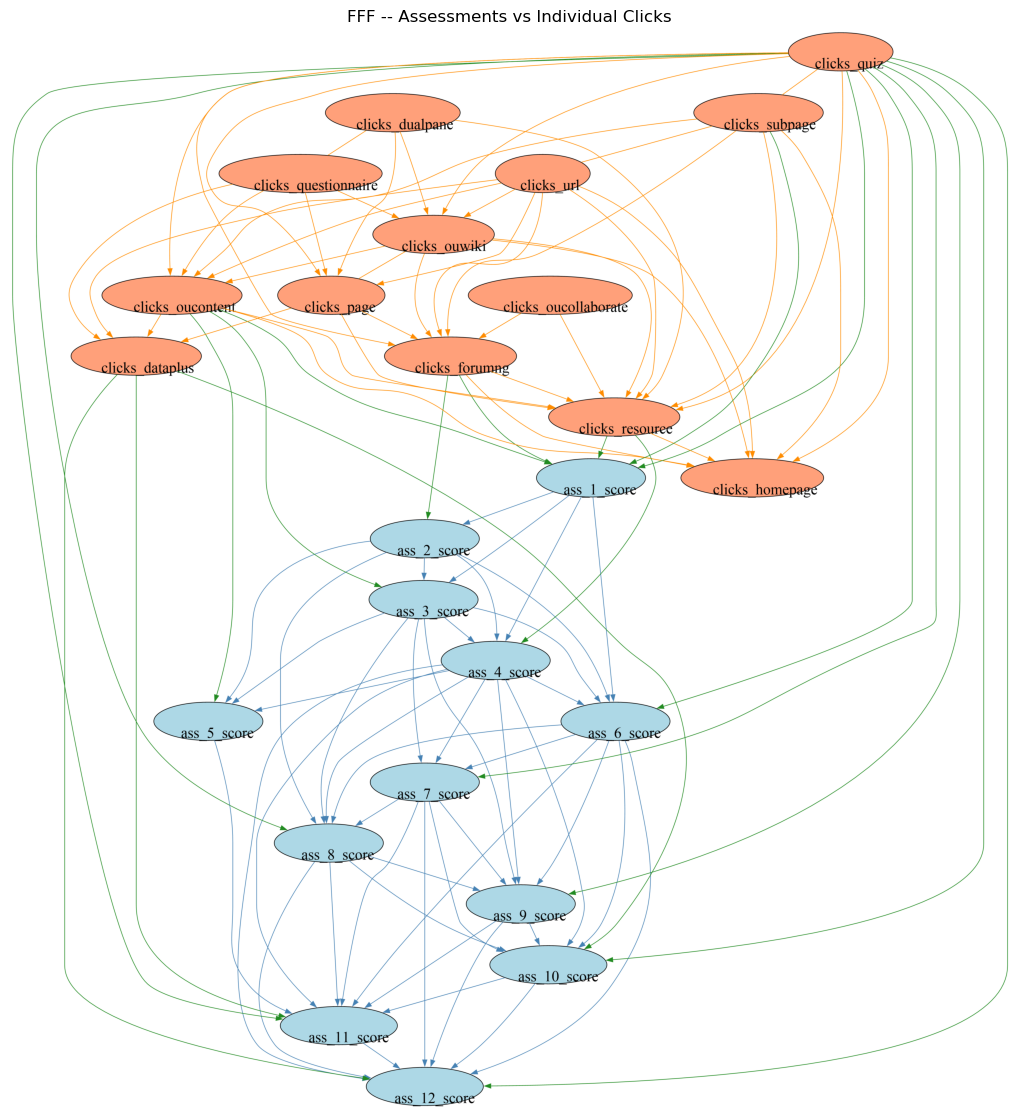

In [32]:
pyd_fff_assclicks = GraphUtils.to_pydot(cg_fff.G, labels=node_names_fff)

for node in pyd_fff_assclicks.get_nodes():
    name = node.get_name().strip('"')
    if name.isdigit():
        actual_name = node_names_fff[int(name)]
    else:
        continue
    if actual_name.startswith('ass_'):
        node.set_style('filled')
        node.set_fillcolor('lightblue')
    elif actual_name.startswith('clicks_'):
        node.set_style('filled')
        node.set_fillcolor('lightsalmon')
    node.set_fontsize('18')
    node.set_fixedsize('false')
    node.set_margin('0.25,0.15')

for edge in pyd_fff_assclicks.get_edges():
    src_idx = int(edge.get_source())
    dst_idx = int(edge.get_destination())
    src = node_names_fff[src_idx]
    dst = node_names_fff[dst_idx]
    if src.startswith('ass_') and dst.startswith('ass_'):
        edge.set_color('steelblue')
    elif src.startswith('clicks_') and dst.startswith('clicks_'):
        edge.set_color('darkorange')
    else:
        edge.set_color('forestgreen')

png_bytes_fff_assclicks = pyd_fff_assclicks.create_png(prog=dot_path)
with open(r"C:\Users\Disha Sharma\Desktop\Paper_1\ModuleWise\FFF_DAG4_assessments_vs_clicks.png", "wb") as f:
    f.write(png_bytes_fff_assclicks)
img_fff_assclicks = mpimg.imread(io.BytesIO(png_bytes_fff_assclicks), format='png')
plt.figure(figsize=(16, 14))
plt.imshow(img_fff_assclicks)
plt.axis('off')
plt.title("FFF -- Assessments vs Individual Clicks")
plt.show()